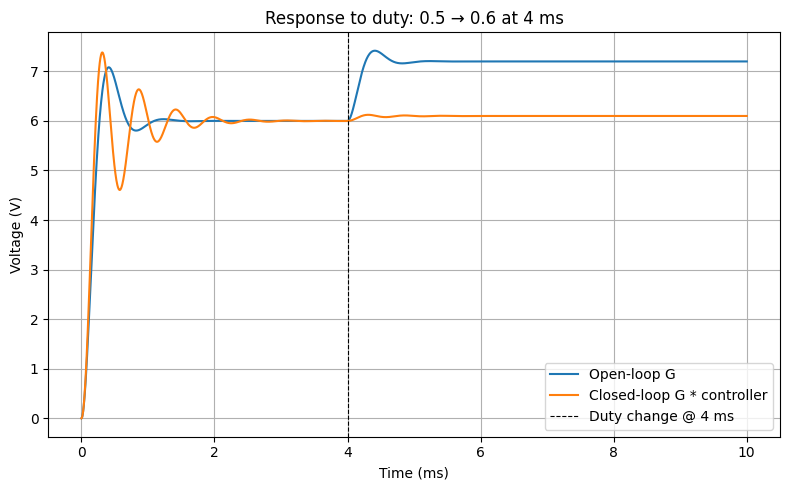

In [22]:
import control as ct
import matplotlib.pyplot as plt
import numpy as np

# --- Parameters ---
L = 660e-6
C = 20e-6
R = 6
Vi = 12

# --- Laplace variable ---
s = ct.TransferFunction.s

# --- Plant and PI ---
G = Vi / (L*C*s**2 + (L/R)*s + 1)
kp = 0.08
ki = 641.8
Dc = kp + (ki / s)

controlled = ct.feedback(G*Dc, 1)


# --- Time vector 0–5 ms ---
t = np.linspace(0, 10e-3, 2000)

# --- Duty profile: 0.5 → 0.6 at 4 ms ---
reference = 6
duty = 0.5

t_change = 4e-3
u_ol = np.where(t < t_change, duty, duty + 0.1)
u_cl = np.where(t < t_change, reference, reference + 0.1)

# --- Simulations ---
t1, y1 = ct.forced_response(G,  T=t, U=u_ol)
t2, y2 = ct.forced_response(controlled, T=t, U=u_cl)

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(t1*1e3, y1, label='Open-loop G')
plt.plot(t2*1e3, y2, label='Closed-loop G * controller')
plt.axvline(t_change*1e3, linestyle='--', linewidth=0.8, color='k',
            label='Duty change @ 4 ms')

plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.title("Response to duty: 0.5 → 0.6 at 4 ms")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

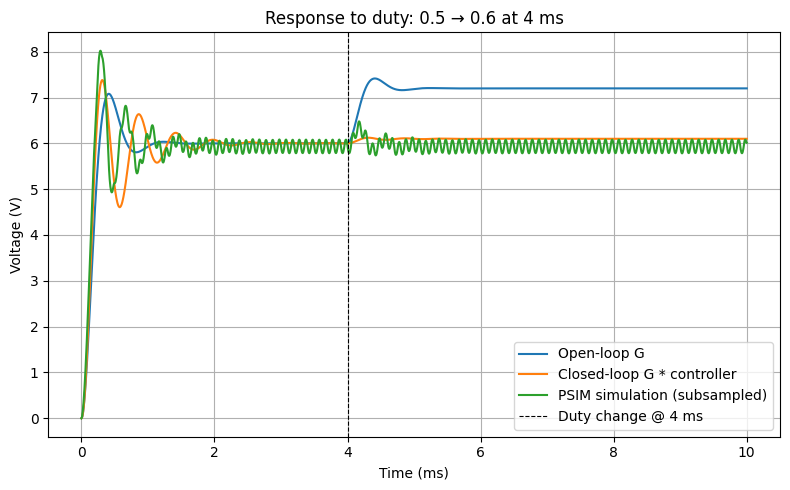

In [23]:
import pandas as pd
from scipy import signal

df = pd.read_csv('data-PSIM.csv')
responsePSIM = df['Vout'].to_numpy()

#subsampling
current = len(responsePSIM)
desired = len(t1)
factor = int(current/desired)

responsePSIM = signal.decimate(responsePSIM, factor)

plt.figure(figsize=(8,5))
plt.plot(t1*1e3, y1, label='Open-loop G')
plt.plot(t2*1e3, y2, label='Closed-loop G * controller')
plt.plot(t2*1e3, responsePSIM, label="PSIM simulation (subsampled)")
plt.axvline(t_change*1e3, linestyle='--', linewidth=0.8, color='k',
            label='Duty change @ 4 ms')

plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.title("Response to duty: 0.5 → 0.6 at 4 ms")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


 PERFORMANCE METRICS (Python sim vs PSIM)
MAE (Mean Absolute Error):  0.210567 V
MSE (Mean Squared Error):   0.104422 V²
Error Signal Power:         0.104422


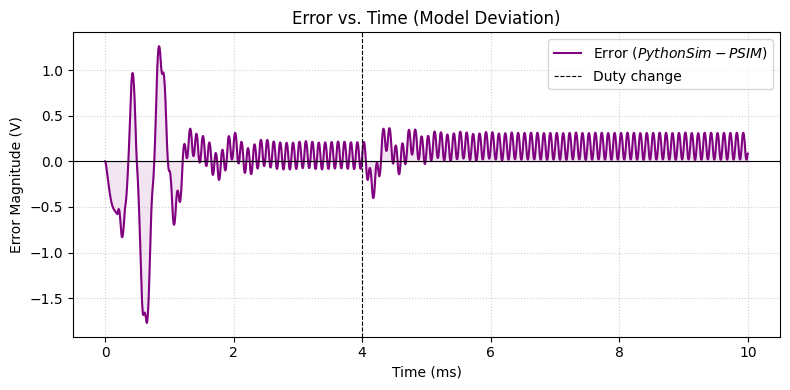

In [24]:
# ==========================================
# --- ADDED METRICS & ERROR ANALYSIS ---
# ==========================================

# 1. Define the Error Signal
# We assume PSIM is the "Ground Truth" and compare the Python Closed-Loop (y2) to it.
error_signal = y2 - responsePSIM

# 2. Calculate Scalar Metrics
mse = np.mean(error_signal**2)          # Mean Squared Error
mae = np.mean(np.abs(error_signal))     # Mean Absolute Error
power_error = np.mean(error_signal**2)  # Power of the error signal (Same as MSE for signals)

# 3. Print Metrics to Console
print("\n" + "="*40)
print(" PERFORMANCE METRICS (Python sim vs PSIM)")
print("="*40)
print(f"MAE (Mean Absolute Error):  {mae:.6f} V")
print(f"MSE (Mean Squared Error):   {mse:.6f} V²")
print(f"Error Signal Power:         {power_error:.6f}")
print("="*40)

# 4. Plot Error vs Time
plt.figure(figsize=(8, 4))

# Plot the instantaneous error
plt.plot(t2 * 1e3, error_signal, color='purple', linewidth=1.5, label='Error ($Python Sim - {PSIM}$)')

# Visual aids
plt.axhline(0, color='black', linestyle='-', linewidth=0.8) # Zero line
plt.axvline(t_change*1e3, linestyle='--', linewidth=0.8, color='k', label='Duty change')
plt.fill_between(t2 * 1e3, error_signal, 0, color='purple', alpha=0.1) # Shade the error area

plt.xlabel("Time (ms)")
plt.ylabel("Error Magnitude (V)")
plt.title("Error vs. Time (Model Deviation)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()